In [1]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq
from dataclasses import dataclass
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pickle
import umap

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.manifold import TSNE

# Extracting and Preparing Data

In [2]:
dataset_root = Path(r"./dataset") # Raw string works without escaping \


@dataclass
class Case():
    info: pd.DataFrame
    measurements: pd.DataFrame


class RawDataset():

    def __init__(self, root, unit = "VG4", load_training=False, load_synthetic=False) -> None:
        
        
        read_pq_file = lambda f: pq.read_table(root / f).to_pandas()
        
        
        cases = {
            "test": [f"{unit}_generator_data_testing_real_measurements.parquet", root / f"{unit}_generator_data_testing_real_info.csv" ], 
        }
        
        if load_training:
            cases = {
                **cases,
                "train": [f"{unit}_generator_data_training_measurements.parquet", root / f"{unit}_generator_data_training_info.csv" ], 
            }
        
        if load_synthetic:
            cases = {
                **cases,
                "test_s01": [f"{unit}_generator_data_testing_synthetic_01_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_01_info.csv"], 
                "test_s02": [f"{unit}_generator_data_testing_synthetic_02_measurements.parquet", root / f"{unit}_generator_data_testing_synthetic_02_info.csv"]
            }
        
        
        self.data_dict = dict()
        
        for id_c, c in cases.items():
            # if you need to verify the parquet header:
            # pq_rows = RawDataset.read_parquet_schema_df(root / c[0])
            info = pd.read_csv(c[1])
            measurements = read_pq_file(c[0])
            self.data_dict[id_c] = Case(info, measurements)
            
        
        
    @staticmethod
    def read_parquet_schema_df(uri: str) -> pd.DataFrame:
        """Return a Pandas dataframe corresponding to the schema of a local URI of a parquet file.

        The returned dataframe has the columns: column, pa_dtype
        """
        # Ref: https://stackoverflow.com/a/64288036/
        schema = pq.read_schema(uri, memory_map=True)
        schema = pd.DataFrame(({"column": name, "pa_dtype": str(pa_dtype)} for name, pa_dtype in zip(schema.names, schema.types)))
        schema = schema.reindex(columns=["column", "pa_dtype"], fill_value=pd.NA)  # Ensures columns in case the parquet file has an empty dataframe.
        return schema

## Splitting the dataset

In [3]:
# Define Operating Modes
Operating_modes_name = [
    "turbine_mode", "equilibrium_turbine_mode", "pump_mode", "equilibrium_pump_mode",
    "short_circuit_mode", "equilibrium_short_circuit_mode", "machine_on", "machine_off", 
    "dyn_only_on", "all"
]

# Time Series Extraction Functions
def extracting_name_groups_time_series(rds, set_type):
    df_name_control_sensors = rds.data_dict[set_type].info
    control_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == True) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    sensors_time_series_name = df_name_control_sensors[
        (df_name_control_sensors['control_signal'] == False) &
        (df_name_control_sensors["signal_type"] == "Measurement")
    ]
    return control_time_series_name["attribute_name"], sensors_time_series_name["attribute_name"]

def extracting_groups_time_series(rds, set_type):
    control_time_series_name, sensors_time_series_name = extracting_name_groups_time_series(rds, set_type=set_type)
    control_df = rds.data_dict[set_type].measurements[control_time_series_name]
    sensors_df = rds.data_dict[set_type].measurements[sensors_time_series_name]
    operating_modes_df = rds.data_dict[set_type].measurements[Operating_modes_name]
    return control_df, sensors_df, operating_modes_df

def get_indexes_operating_mode(operating_modes_df, operating_conditions):
    mask = pd.Series([True] * len(operating_modes_df), index=operating_modes_df.index)
    for column, value in operating_conditions.items():
        mask &= (operating_modes_df[column] == value)
    return operating_modes_df[mask].index

# Helper functions for feature extraction 
def feature_extraction(df, feature_prefixes, new_feature_name):
    feature_columns = df.columns[df.columns.str.startswith(tuple(feature_prefixes))]
    df[new_feature_name] = df[feature_columns].sum(axis=1)
    df.drop(columns=feature_columns, inplace=True)
    return df

# Helper functions for normalization
def normalize_features(df,scaler, fit = True):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns]) if fit else scaler.transform(df[numerical_columns])
    return df

def dynamic_group_features(df):
    feature_groups = {
        'voltage_current': df.columns[df.columns.str.startswith(("exc", "ph", "elec", "mid", "neutral"))].tolist(),
        'stator_temperature': df.columns[df.columns.str.startswith("stat_") & 
                                         df.columns.str.contains("coil|magn")].tolist(),
        'cooling_system': df.columns[df.columns.str.startswith("air_circ_")].tolist(),
        'heat_exchanger': df.columns[df.columns.str.startswith("water_circ_")].tolist()
    }

    # Flatten the list of all grouped features
    grouped_features = [feature for group in feature_groups.values() for feature in group]
    # Find complementary features
    complementary_features = [col for col in df.columns if col not in grouped_features]
    
    feature_groups['complementary'] = complementary_features

    return feature_groups

def preprocess_hydraulic_data(rds, set_type, operating_conditions, scaler, fit):
    """
    Preprocess the hydraulic site data to return normalized control and sensor signals filtered by operating conditions.

    Parameters:
    - rds: RawDataset object containing the data dictionary
    - set_type: Type of dataset to use ('train', 'test', etc.)
    - feature_group: The group of sensor features to select for preprocessing
    - operating_conditions: A dictionary specifying operating conditions to filter the data
    
    Returns:
    - Dictionary with two normalized and filtered DataFrames: control signals and sensor signals
    """
    # Step 1: Extract control, sensor, and operating mode time series
    control_df, sensors_df, operating_modes_df = extracting_groups_time_series(rds, set_type=set_type)

    # Step 2: Filter based on operating conditions if specified
    if operating_conditions:
        indexes = get_indexes_operating_mode(operating_modes_df, operating_conditions)
        control_df = control_df.loc[indexes]
        sensors_df = sensors_df.loc[indexes]
        
    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_df.columns if "water" in col and "opening" in col]
    control_df = feature_extraction(control_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_df.columns if "injector" in col and "opening" in col]
    control_df = feature_extraction(control_df, injector_opening_features, "injector_opening_sum")

    # Step 4 : Extract the groups of interest
    grouped_data = dynamic_group_features(sensors_df)
    selected_sensor_data = []
    for key in grouped_data.keys():
        selected_sensor_data.append(sensors_df[grouped_data[key]])

    sensors_df = pd.concat([selected_sensor_data[i] for i in range(5)], axis=1)

    # Step 5 : Concatenate the df into one
    df_signals = pd.concat([control_df, sensors_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    df_signals = normalize_features(df_signals, scaler=scaler, fit=fit)


    return df_signals


def preprocess_hydraulic_synthetic_dataset(rds_train, training_df,
                                           unit, number, Type, scaler, turbine_or_pump=True):
    
    #file_path = "./dataset/synthetic_anomalies/VG5_anomaly_01_type_a.parquet"

    file_path = f"./dataset/synthetic_anomalies/{unit}_anomaly_{number}_type_{Type}.parquet"

    rds = pd.read_parquet(file_path).drop(columns="ground_truth")

    ### Keep only the turbine mode
    
    if turbine_or_pump:
        rds = rds[rds["equilibrium_turbine_mode"]==True]
    else:
        rds = rds[rds["equilibrium_pump_mode"]==True]

    control_names, sensor_names = extracting_name_groups_time_series(rds_train, "test")

    control_syn_df = rds[control_names].copy()
    sensor_syn_df = rds[sensor_names].copy()

    # Select features containing both 'water' and 'opening' in their name
    water_opening_features = [col for col in control_syn_df.columns if "water" in col and "opening" in col]
    control_syn_df = feature_extraction(control_syn_df, water_opening_features, "water_opening_sum")

    # Select features containing both 'injector' and 'opening' in their name
    injector_opening_features = [col for col in control_syn_df.columns if "injector" in col and "opening" in col]
    control_syn_df = feature_extraction(control_syn_df, injector_opening_features, "injector_opening_sum")

    # Step 5 : Concatenate the df into one
    test_syn_df = pd.concat([control_syn_df, sensor_syn_df], axis=1)

    # Step 6: Normalize the signals DataFrame
    test_syn_df = test_syn_df[training_df.columns]
    # Transform the test_syn_df
    scaled_array = scaler.transform(test_syn_df)

    # Convert the numpy array back to a DataFrame
    scaled_df = pd.DataFrame(scaled_array, columns=test_syn_df.columns, index=test_syn_df.index)

    return scaled_df

## Obtaining the labels for the synthetic datasets

In [4]:
def obtain_ground_truth(dataset_root, unit="VG5", test_set="01", anomaly_type="a"):

    # Load anomaly data
    anomaly_file = Path(dataset_root) / "synthetic_anomalies" / f"{unit}_anomaly_{test_set}_type_{anomaly_type}.parquet"
    anomaly_data = pq.read_table(anomaly_file).to_pandas()
    ground_truth = anomaly_data["ground_truth"]
    #ground_truth = 1-anomaly_data['ground_truth'] # Setting healthy state to 1
    #ground_truth[ground_truth==0]=-1 # Setting anomaly to -1
    ground_truth_index = anomaly_data.index
    
    return ground_truth, ground_truth_index

def plot_ground_truth(ground_truth, ground_truth_index, unit, test_set, anomaly_type):
    """Plot ground truth data"""
    plt.figure(figsize=(15, 4))
    plt.plot(ground_truth_index, ground_truth, 'b-', linewidth=1)
    
    plt.title(f'Ground Truth - {unit}, Set {test_set}, Type {anomaly_type} (1 = Healthy, -1 = Unhealthy)')
    plt.ylim(-1.1, 1.1)
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel('Anomaly Present')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Loading Train Dataset and Preparing for training

In [5]:
rds_u5_train = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=True)

In [6]:
# Turbine Steady State Operation
operating_conditions_set = {
    "dyn_only_on": False, "turbine_mode": True, "equilibrium_turbine_mode": True, "short_circuit_mode": False
}

scaler=MinMaxScaler()

# Preprocess data to get normalized control and sensor signals based on conditions
rds_u5_turb_ss_volt = preprocess_hydraulic_data(
    rds_u5_train, set_type="train", operating_conditions=operating_conditions_set,
    scaler=scaler, fit = True
)

del rds_u5_train # To free memory

In [7]:
training_df = rds_u5_turb_ss_volt[::10]

del rds_u5_turb_ss_volt

In [8]:
training_df.shape

(33224, 84)

## Plotting on the synthetic dataset

In [9]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'a',
    'set_type':'test_s01'
}

In [10]:
rds_u5_buffer = RawDataset(dataset_root, "VG5", load_synthetic=False, load_training=False)

test_syn_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS["unit"],
                                                     number = SYNTHETIC_PARAMS["test_set"],
                                                     Type = SYNTHETIC_PARAMS["anomaly_type"],
                                                     scaler=scaler)

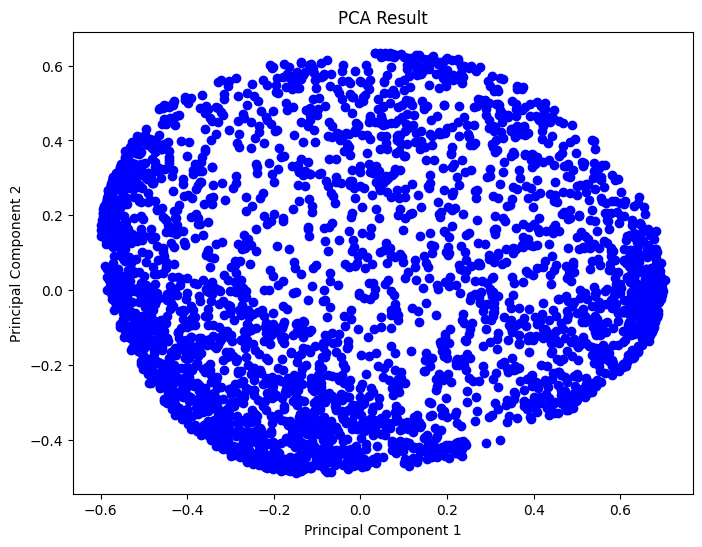

In [11]:
# Apply PCA
pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
pca_result = pca.fit_transform(training_df[::10])

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

/tmp/ipykernel_31869/941319094.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c="blue", cmap='viridis', marker='o')


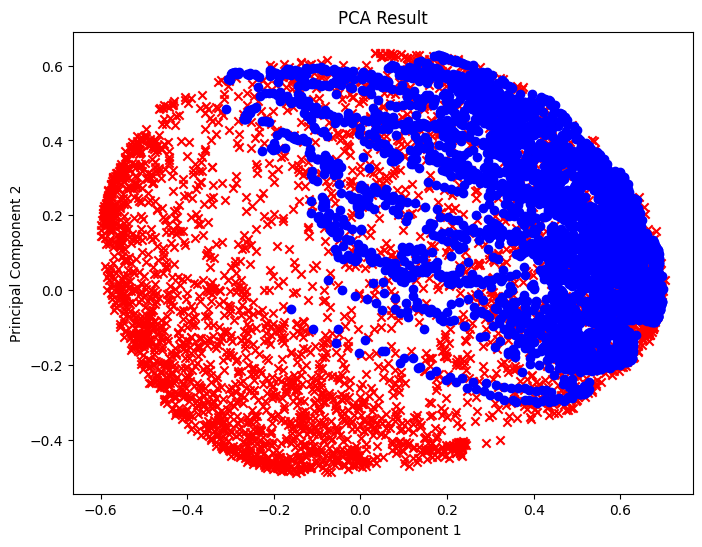

In [12]:
pca_result_test = pca.transform(test_syn_df[::10])

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='red', marker='x')
scatter = plt.scatter(pca_result_test[:, 0], pca_result_test[:, 1], c="blue", cmap='viridis', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
#plt.colorbar(scatter, label='Label')
plt.show()

#### Trying umap

In [13]:
# Apply UMAP
umap_model = umap.UMAP(n_components=2)
umap_result = umap_model.fit_transform(training_df[::10])

# Apply UMAP
umap_result_test = umap_model.transform(test_syn_df[::10])



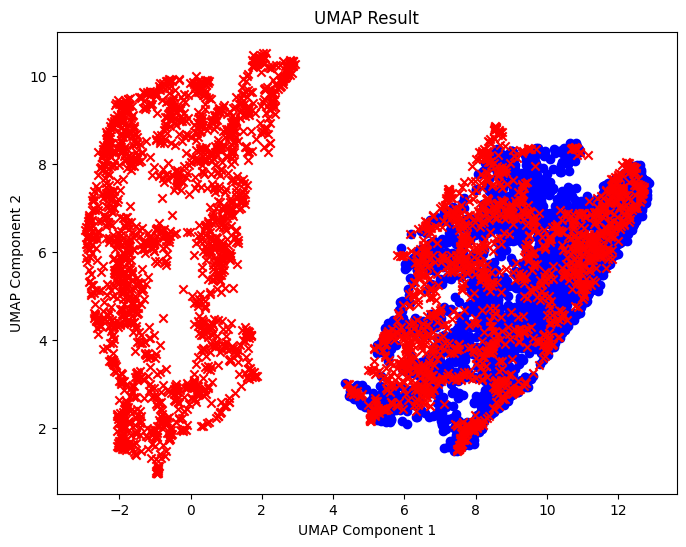

In [14]:
# Plot UMAP result
plt.figure(figsize=(8, 6))
plt.scatter(umap_result_test[:, 0], umap_result_test[:, 1], c="blue", marker='o')
plt.scatter(umap_result[:, 0], umap_result[:, 1], c='red', marker='x')
plt.title('UMAP Result')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

### T-sne

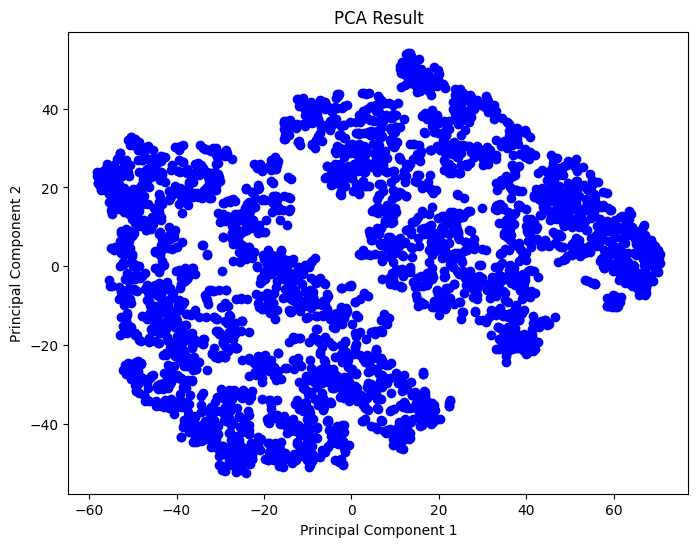

In [15]:
t_sne = TSNE(n_components=2)

t_sne_result = t_sne.fit_transform(training_df[::10])

# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='blue', marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [16]:
t_sne_test_result = t_sne.fit_transform(test_syn_df[::10])

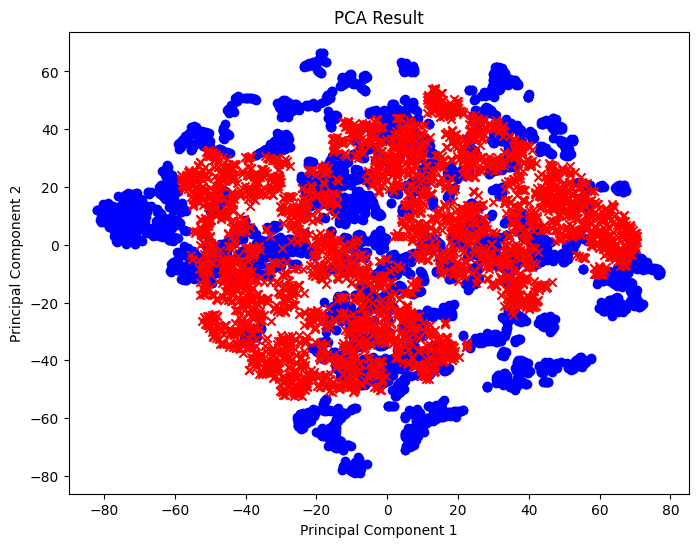

In [17]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_test_result[:, 0], t_sne_test_result[:, 1], c='blue', marker='o')
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='red', marker='x')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Synthetic with labels

In [18]:
ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS['unit'],
    test_set=SYNTHETIC_PARAMS['test_set'],
    anomaly_type=SYNTHETIC_PARAMS['anomaly_type']
)

In [19]:
# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

In [20]:
rds_u5_synth.data_dict.keys()

dict_keys(['test', 'test_s01', 'test_s02'])

In [21]:
# Load only synthetic test data (no training data needed)
rds_u5_synth = RawDataset(dataset_root, "VG5", load_synthetic=True, load_training=False)

# Process synthetic datasets
rds_u5_synth_processed = preprocess_hydraulic_data(
    rds_u5_synth, set_type=SYNTHETIC_PARAMS['set_type'], operating_conditions=operating_conditions_set,  # set at the top
    scaler=scaler, fit=False
)

del rds_u5_synth

In [22]:
test_ground_truth = ground_truth.loc[test_syn_df.index]

In [23]:
t_sne_test_syn_result = t_sne.fit_transform(test_syn_df[::20])

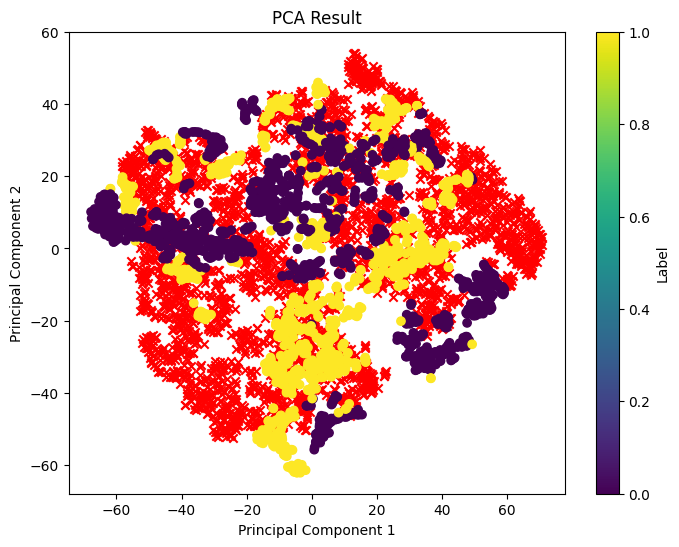

In [24]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='red', marker='x')
scatter = plt.scatter(t_sne_test_syn_result[:, 0], t_sne_test_syn_result[:, 1], c=test_ground_truth[::20],cmap="viridis", marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Label')
plt.show()

### testing on a second synthetic set

In [25]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS_2 = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'b',
    'set_type':'test_s01'
}

In [26]:
test_syn_2_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS_2["unit"],
                                                     number = SYNTHETIC_PARAMS_2["test_set"],
                                                     Type = SYNTHETIC_PARAMS_2["anomaly_type"],
                                                     scaler=scaler)

In [27]:
ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS_2['unit'],
    test_set=SYNTHETIC_PARAMS_2['test_set'],
    anomaly_type=SYNTHETIC_PARAMS_2['anomaly_type']
)

In [28]:
test_ground_truth = ground_truth.loc[test_syn_2_df.index]

In [29]:
t_sne_test_syn_result = t_sne.fit_transform(test_syn_2_df[::10])

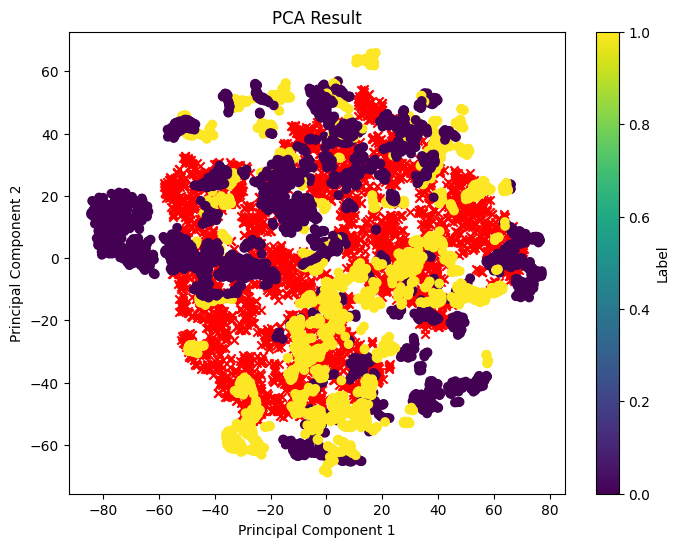

In [30]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='red', marker='x')
scatter = plt.scatter(t_sne_test_syn_result[:, 0], t_sne_test_syn_result[:, 1], c=test_ground_truth[::10],cmap="viridis", marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Label')
plt.show()

#### Third anomaly

In [31]:
# LOAD PARAMETERS
SYNTHETIC_PARAMS_3 = {
    'unit': 'VG5',
    'test_set': '01',
    'anomaly_type': 'c',
    'set_type':'test_s01'
}

test_syn_3_df = preprocess_hydraulic_synthetic_dataset(rds_train=rds_u5_buffer,
                                                     training_df=training_df, 
                                                     unit=SYNTHETIC_PARAMS_3["unit"],
                                                     number = SYNTHETIC_PARAMS_3["test_set"],
                                                     Type = SYNTHETIC_PARAMS_3["anomaly_type"],
                                                     scaler=scaler)

ground_truth, ground_truth_index = obtain_ground_truth(
    dataset_root,
    unit=SYNTHETIC_PARAMS_3['unit'],
    test_set=SYNTHETIC_PARAMS_3['test_set'],
    anomaly_type=SYNTHETIC_PARAMS_3['anomaly_type']
)

test_ground_truth = ground_truth.loc[test_syn_3_df.index]

In [32]:
t_sne_test_syn_result = t_sne.fit_transform(test_syn_3_df[::10])

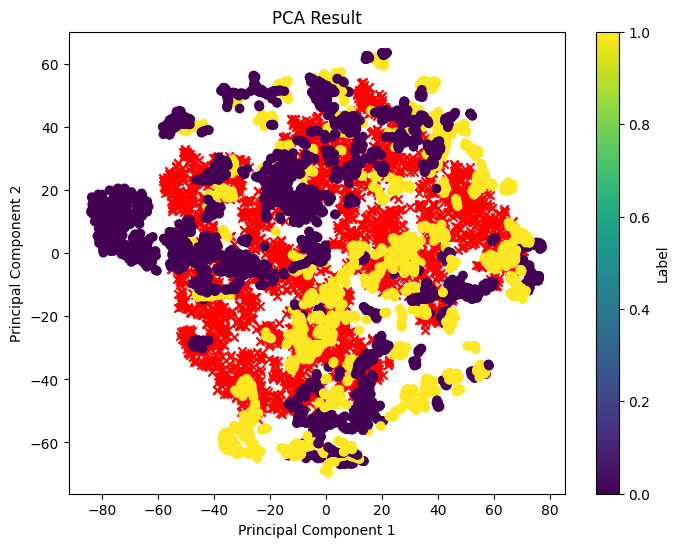

In [33]:
# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(t_sne_result[:, 0], t_sne_result[:, 1], c='red', marker='x')
scatter = plt.scatter(t_sne_test_syn_result[:, 0], t_sne_test_syn_result[:, 1], c=test_ground_truth[::10],cmap="viridis", marker='o')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Label')
plt.show()